<a href="https://colab.research.google.com/github/LamNoem/NumberClassification/blob/main/number_classificatoin_model_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision


In [ ]:
#Import Libraries
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
trainset = datasets.MNIST('train', download = True, train = True, transform = transforms.ToTensor())
testset = datasets.MNIST('test', download = True, train = False, transform = transforms.ToTensor())

for item in testset:
  print(type(testset))
  break

<class 'torchvision.datasets.mnist.MNIST'>


In [ ]:
trainloader = DataLoader(trainset, batch_size = 32, shuffle = True)
testloader = DataLoader(testset, batch_size = 1, shuffle = True)

In [ ]:
for images, labels in testloader:
  print(images, labels)
  break

tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
class MyModel(nn.Module):
  def __init__(self):
    #fill out
    super(MyModel, self).__init__()
    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 5, kernel_size = 3)
    #input is 1 28 by 28 matrix
    #output is 5 26 by 26 matrices - - based on convolution math/process/hyperparameters
    self.conv2 = nn.Conv2d(in_channels = 5, out_channels = 3, kernel_size = 4, stride = 2)
    #input is 5 26 by 26 matrices
    #output is 3 12 by 12 matrices  - based on convolution math/process/hyperparameters
    self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding=0)
    #input is 3 12 by 12 matices
    #output is 3 6 by 6 matrices
    #self.linear1 = nn.Linear(3 * 6 * 6, 1000)
    self.linear1 = nn.LazyLinear(1000)
    #input is 3*12*12 = 432 because the convolutional layer before outputs/returns 3 12 by 12 matrices and passes it into linear 1
    # 432 is represented in the 1D shape. the (conv2) output's 1D shape will be [batch, 3*12*12 = 432]. The 1D shape is seen by typing
    self.linear2 = nn.Linear(1000, 500)
    self.linear3 = nn.Linear(500, 250)
    self.linear4 = nn.Linear(250, 125)
    self.linear5 = nn.Linear(125, 10)
    # output is 10 bc it will return 10 values, corresponding to the 10 possible numbers/outputs (from 0 to 9)
    #self.dropout = nn.Dropout(0.2) #dropout is only used during training not evaluation


  def forward(self, images):
    x = self.conv1(images)
    x = self.conv2(x)
    x = self.pool1(x)
    x = x.flatten(start_dim = 1)
    x = torch.relu(self.linear1(x))
    #x = self.dropout(x)
    x = torch.relu(self.linear2(x))
    #x = self.dropout(x)
    x = torch.relu(self.linear3(x))
    #x = self.dropout(x)
    x = torch.relu(self.linear4(x))
    #x = self.dropout(x)
    x = self.linear5(x) #will return 10 values, corresponding to the 10 possible numbers/outputs (from 0 to 9)
    #x = self.dropout(x)
    x = F.softmax(x, dim = 1) #will return 10 probabilties, corresponding to the probabilities of each number
    # when it comes to activation functions that return probabilities: Sigmoid is used for binary classification methods where we only have 2 classes, while SoftMax applies to multiclass problems
    return x

model = MyModel()


In [ ]:
#loading model
import torch
import torch.nn as nn
model_path = "/content/drive/MyDrive/UofT Computer Vision"
model_name = 'number_predict11.pth'
PATH = model_path + "/" + model_name
model = MyModel()
model.load_state_dict(torch.load(PATH)) #loading named model from drive
model.eval() #lets model know that its evaluating and so turns off dropout

MyModel(
  (conv1): Conv2d(1, 5, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(5, 3, kernel_size=(4, 4), stride=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): LazyLinear(in_features=0, out_features=1000, bias=True)
  (linear2): Linear(in_features=1000, out_features=500, bias=True)
  (linear3): Linear(in_features=500, out_features=250, bias=True)
  (linear4): Linear(in_features=250, out_features=125, bias=True)
  (linear5): Linear(in_features=125, out_features=10, bias=True)
)

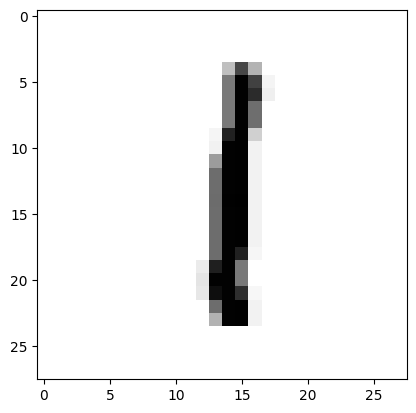

In [ ]:
plt.imshow(images[0].numpy().squeeze(), cmap = 'gray_r')

In [ ]:
print(labels[0])
print(images[0].shape)
x = images[0]
y = model(x)

tensor(1)
torch.Size([1, 28, 28])


RuntimeError: ignored

torch.Size([1, 1, 28, 28])
tensor([9])
[[1.4925353158353253e-16, 2.254599501885779e-13, 2.319493635179258e-15, 2.3062134424378655e-09, 4.687945420300821e-06, 7.139623094121195e-12, 1.0980391670542302e-17, 8.890859817256569e-07, 4.17333767543937e-09, 0.9999945163726807]]
[9]


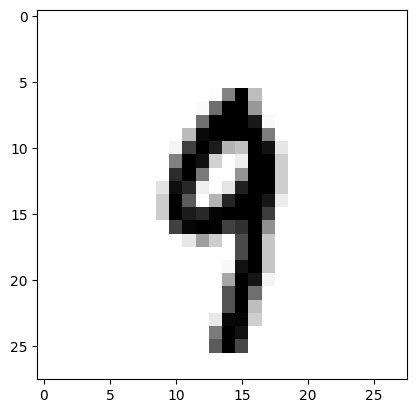

In [ ]:
for images, labels in testloader:
  print(images.shape)
  print(labels)
  y_hat = model(images)
  y_pred = torch.argmax(y_hat, dim = 1)
  print(y_hat.tolist())
  print(y_pred.tolist())
  plt.imshow(images.numpy().squeeze(), cmap = 'gray_r')
  break

